# Stream Pipeline Evaluation

This notebook evaluates the **Spark streaming pipeline performance** using the metrics collected from `spark_streaming.py`.


In [12]:
!pip install pandas matplotlib seaborn

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Set file paths

In [14]:
RESULT_DIR = "../results"
CHART_DIR = "../charts"

STREAM_METRICS_PATH = os.path.join(RESULT_DIR, "stream_pipeline_metrics.csv")

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

print("Streaming metrics path:", STREAM_METRICS_PATH)

Streaming metrics path: ../results\stream_pipeline_metrics.csv


Load streaming metrics

The file `stream_pipeline_metrics.csv` was generated automatically by `spark_streaming.py` during the Spark Structured Streaming run.


In [15]:
stream_df = pd.read_csv(STREAM_METRICS_PATH)

print("Shape:", stream_df.shape)
stream_df.head()

Shape: (97, 6)


,mode,batch_id,records_processed,processing_time_seconds,throughput_records_per_second,processed_at
0,Streaming,1,72,4.712281,15.279225,2026-07-06T09:35:50.015842+00:00
1,Streaming,2,105,5.598488,18.755063,2026-07-06T09:35:56.486172+00:00
2,Streaming,3,125,6.464705,19.335762,2026-07-06T09:36:03.621776+00:00
3,Streaming,4,136,6.893334,19.729205,2026-07-06T09:36:11.077347+00:00
4,Streaming,5,145,7.483101,19.376995,2026-07-06T09:36:19.090662+00:00


Basic checking

In [16]:
print(stream_df.info())
print("\nMissing values:")
print(stream_df.isna().sum())

print("\nSummary statistics:")
stream_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   mode                           97 non-null     object 
 1   batch_id                       97 non-null     int64  
 2   records_processed              97 non-null     int64  
 3   processing_time_seconds        97 non-null     float64
 4   throughput_records_per_second  97 non-null     float64
 5   processed_at                   97 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 4.7+ KB
None

Missing values:
mode                             0
batch_id                         0
records_processed                0
processing_time_seconds          0
throughput_records_per_second    0
processed_at                     0
dtype: int64

Summary statistics:


,batch_id,records_processed,processing_time_seconds,throughput_records_per_second
count,97.000000,97.000000,97.000000,97.000000
mean,49.000000,194.175258,9.787415,19.805562
std,28.145456,20.372577,0.921874,0.555308
min,1.000000,72.000000,4.712281,15.279225
25%,25.000000,200.000000,9.948484,19.708758
50%,49.000000,200.000000,10.031873,19.892296
75%,73.000000,200.000000,10.106183,20.012422
max,97.000000,200.000000,10.612073,20.556151


Streaming pipeline summary

In [17]:
total_records = stream_df["records_processed"].sum()
total_processing_time = stream_df["processing_time_seconds"].sum()
micro_batches = stream_df["batch_id"].nunique()
average_batch_size = stream_df["records_processed"].mean()
average_processing_time = stream_df["processing_time_seconds"].mean()
average_throughput = stream_df["throughput_records_per_second"].mean()
overall_throughput = total_records / total_processing_time if total_processing_time > 0 else 0
min_throughput = stream_df["throughput_records_per_second"].min()
max_throughput = stream_df["throughput_records_per_second"].max()

stream_summary = pd.DataFrame([{
    "pipeline_mode": "Spark Structured Streaming",
    "total_records_processed": total_records,
    "micro_batches_processed": micro_batches,
    "average_batch_size": average_batch_size,
    "total_processing_time_seconds": total_processing_time,
    "average_processing_time_per_batch_seconds": average_processing_time,
    "average_throughput_records_per_second": average_throughput,
    "overall_throughput_records_per_second": overall_throughput,
    "minimum_throughput_records_per_second": min_throughput,
    "maximum_throughput_records_per_second": max_throughput
}])

stream_summary

,pipeline_mode,total_records_processed,micro_batches_processed,average_batch_size,total_processing_time_seconds,average_processing_time_per_batch_seconds,average_throughput_records_per_second,overall_throughput_records_per_second,minimum_throughput_records_per_second,maximum_throughput_records_per_second
0,Spark Structured Streaming,18835,97,194.175258,949.379295,9.787415,19.805562,19.839278,15.279225,20.556151


Save streaming pipeline summary

In [18]:
summary_path = os.path.join(RESULT_DIR, "stream_pipeline_summary.csv")
stream_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: ../results\stream_pipeline_summary.csv


Throughput by micro-batch

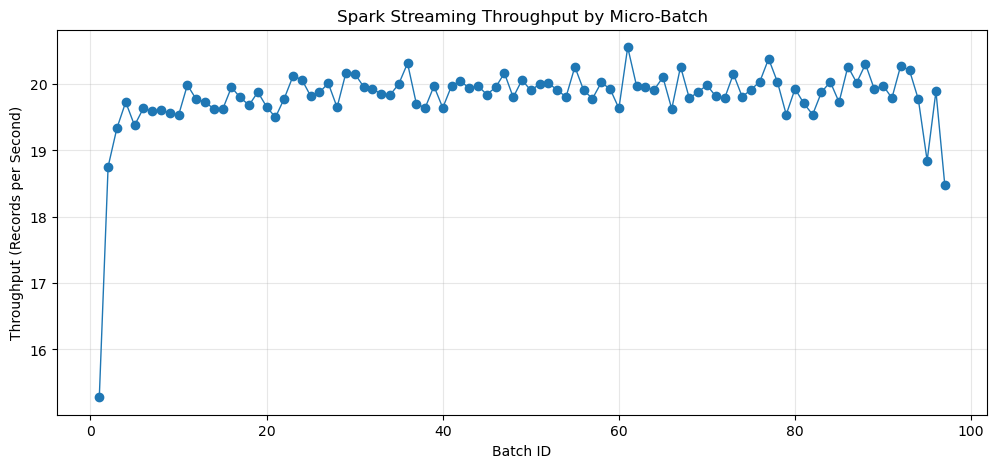

Saved: ../charts\streaming_throughput_by_microbatch.png


In [19]:
plt.figure(figsize=(12, 5))
plt.plot(
    stream_df["batch_id"],
    stream_df["throughput_records_per_second"],
    marker="o",
    linewidth=1
)
plt.title("Spark Streaming Throughput by Micro-Batch")
plt.xlabel("Batch ID")
plt.ylabel("Throughput (Records per Second)")
plt.grid(alpha=0.3)

chart_path = os.path.join(CHART_DIR, "streaming_throughput_by_microbatch.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)

Processing time by micro-batch

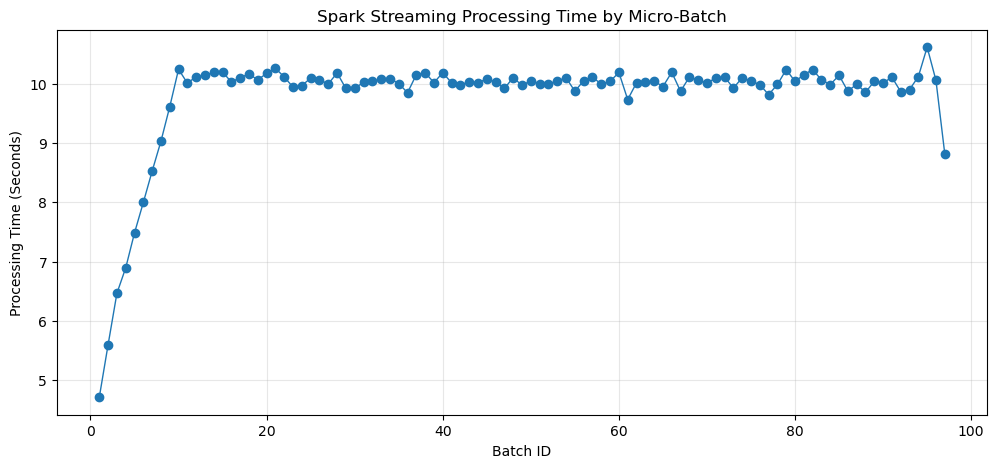

Saved: ../charts\streaming_processing_time_by_microbatch.png


In [20]:
plt.figure(figsize=(12, 5))
plt.plot(
    stream_df["batch_id"],
    stream_df["processing_time_seconds"],
    marker="o",
    linewidth=1
)
plt.title("Spark Streaming Processing Time by Micro-Batch")
plt.xlabel("Batch ID")
plt.ylabel("Processing Time (Seconds)")
plt.grid(alpha=0.3)

chart_path = os.path.join(CHART_DIR, "streaming_processing_time_by_microbatch.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)

Records processed by micro-batch

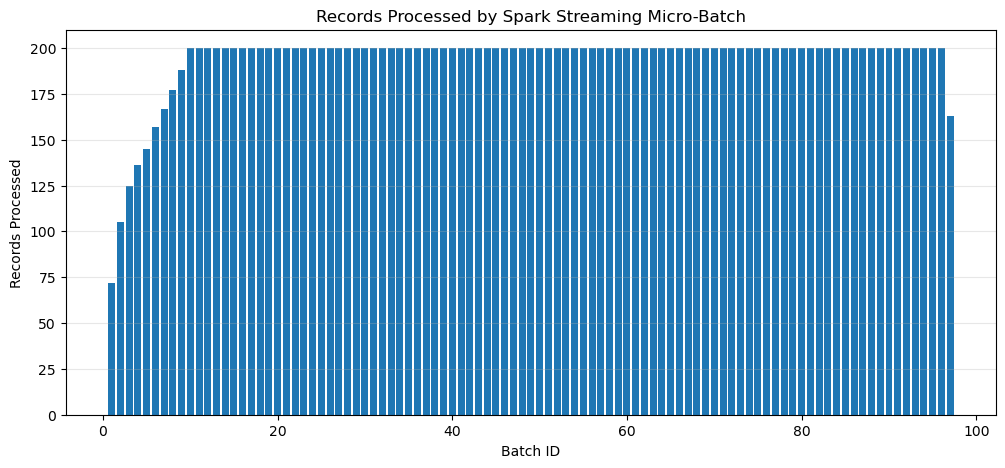

Saved: ../charts\streaming_records_by_microbatch.png


In [21]:
plt.figure(figsize=(12, 5))
plt.bar(
    stream_df["batch_id"],
    stream_df["records_processed"]
)
plt.title("Records Processed by Spark Streaming Micro-Batch")
plt.xlabel("Batch ID")
plt.ylabel("Records Processed")
plt.grid(axis="y", alpha=0.3)

chart_path = os.path.join(CHART_DIR, "streaming_records_by_microbatch.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)

Key metrics table for report

In [22]:
report_table = pd.DataFrame({
    "Metric": [
        "Total records processed",
        "Spark micro-batches processed",
        "Average batch size",
        "Total measured micro-batch processing time (seconds)",
        "Average processing time per batch (seconds)",
        "Average throughput (records/second)",
        "Overall throughput (records/second)",
        "Minimum throughput (records/second)",
        "Maximum throughput (records/second)"
    ],
    "Observed Value": [
        f"{total_records:,.0f}",
        f"{micro_batches:,.0f}",
        f"{average_batch_size:.2f}",
        f"{total_processing_time:.2f}",
        f"{average_processing_time:.2f}",
        f"{average_throughput:.2f}",
        f"{overall_throughput:.2f}",
        f"{min_throughput:.2f}",
        f"{max_throughput:.2f}"
    ]
})

report_table_path = os.path.join(RESULT_DIR, "stream_pipeline_report_table.csv")
report_table.to_csv(report_table_path, index=False, encoding="utf-8-sig")

print("Saved:", report_table_path)
report_table

Saved: ../results\stream_pipeline_report_table.csv


,Metric,Observed Value
0,Total records processed,"18,835"
1,Spark micro-batches processed,97
2,Average batch size,194.18
3,Total measured micro-batch processing time (se...,949.38
4,Average processing time per batch (seconds),9.79
5,Average throughput (records/second),19.81
6,Overall throughput (records/second),19.84
7,Minimum throughput (records/second),15.28
8,Maximum throughput (records/second),20.56


## Summary

Generated outputs:

- `results/stream_pipeline_summary.csv`
- `results/stream_pipeline_report_table.csv`
- `results/stream_pipeline_interpretation.txt`
- `charts/streaming_throughput_by_microbatch.png`
- `charts/streaming_processing_time_by_microbatch.png`
- `charts/streaming_records_by_microbatch.png`

These outputs can be used in the final report under **Streaming Pipeline Results** or **Optimization and Comparison**.
